In [1]:
# ═══════════════════════════════════════════════════════
# CELDA 1: Imports
# ═══════════════════════════════════════════════════════
!pip install numpy scikit-learn tensorflow matplotlib seaborn -q

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, hamming_loss, multilabel_confusion_matrix)

FINGER_NAMES = ["Pulgar", "Índice", "Medio", "Anular", "Meñique"]

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ═══════════════════════════════════════════════════════
# CELDA 2: Carga del Dataset
# ═══════════════════════════════════════════════════════
import gdown

if not os.path.exists("/content/X.npy"):
    gdown.download("https://drive.google.com/uc?id=1KX-okzn_Oo8Mk_3FOmO-siN6Ok6X_iJv",
                   "/content/X.npy", quiet=False)
if not os.path.exists("/content/Y.npy"):
    gdown.download("https://drive.google.com/uc?id=1bGphucb5oTgLkYT2e9UB4ToaapvhKhhw",
                   "/content/Y.npy", quiet=False)

X_full   = np.load("/content/X.npy", mmap_mode='r')
Y_raw    = np.load("/content/Y.npy", allow_pickle=True)
labels_str = Y_raw.reshape(-1).astype(str)

print("X_full shape:", X_full.shape)   # (22801, 128, 128, 3)
print("Clases únicas:", np.unique(labels_str))

Downloading...
From (original): https://drive.google.com/uc?id=1KX-okzn_Oo8Mk_3FOmO-siN6Ok6X_iJv
From (redirected): https://drive.google.com/uc?id=1KX-okzn_Oo8Mk_3FOmO-siN6Ok6X_iJv&confirm=t&uuid=f1dc3d68-0172-433c-b6ee-0e9845f047c6
To: /content/X.npy
100%|██████████| 4.48G/4.48G [00:55<00:00, 81.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1bGphucb5oTgLkYT2e9UB4ToaapvhKhhw
To: /content/Y.npy
100%|██████████| 1.55M/1.55M [00:00<00:00, 10.4MB/s]

X_full shape: (22801, 128, 128, 3)
Clases únicas: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'NULL' 'a' 'b' 'bye' 'c' 'd' 'e'
 'good' 'good morning' 'hello' 'little bit' 'no' 'pardon' 'please'
 'project' 'whats up' 'yes']


In [3]:
# ═══════════════════════════════════════════════════════
# CELDA 3: Filtro dígitos → etiquetas multi-etiqueta + Split
# ═══════════════════════════════════════════════════════
LABEL_TO_FINGERS = {
    "0": [0,0,0,0,0], "1": [0,1,0,0,0], "2": [0,1,1,0,0],
    "3": [1,1,1,0,0], "4": [0,1,1,1,1], "5": [1,1,1,1,1],
    "6": [1,0,0,0,1], "7": [1,0,0,1,0], "8": [1,0,1,0,0], "9": [1,1,0,0,0],
}

digit_labels    = list(LABEL_TO_FINGERS.keys())
mask_digits     = np.isin(labels_str, digit_labels)
indices_digits  = np.where(mask_digits)[0]
y_digits_str    = labels_str[mask_digits]
Y_fingers       = np.array([LABEL_TO_FINGERS[l] for l in y_digits_str], dtype=np.float32)

img_h, img_w, num_channels = X_full.shape[1], X_full.shape[2], X_full.shape[3]
print(f"Muestras: {len(indices_digits)} | Shape img: {img_h}x{img_w}x{num_channels}")
print(f"Y_fingers shape: {Y_fingers.shape}")

idx_all = np.arange(len(indices_digits))
idx_tv, idx_test, Y_tv, Y_test, y_tv_str, y_test_str = train_test_split(
    idx_all, Y_fingers, y_digits_str, test_size=0.15, random_state=42, stratify=y_digits_str)
idx_train, idx_val, Y_train, Y_val, y_train_str, y_val_str = train_test_split(
    idx_tv, Y_tv, y_tv_str, test_size=0.176, random_state=42, stratify=y_tv_str)

real_idx_train = indices_digits[idx_train]
real_idx_val   = indices_digits[idx_val]
real_idx_test  = indices_digits[idx_test]

print(f"Train: {len(real_idx_train)} | Val: {len(real_idx_val)} | Test: {len(real_idx_test)}")

Muestras: 8650 | Shape img: 128x128x3
Y_fingers shape: (8650, 5)
Train: 6058 | Val: 1294 | Test: 1298


In [4]:
# ═══════════════════════════════════════════════════════
# CELDA 4: Generador de batches (sin explotar RAM)
# ═══════════════════════════════════════════════════════
class FingerBatchGenerator(keras.utils.Sequence):
    def __init__(self, X_mmap, real_indices, labels, batch_size=32, augment=False):
        self.X       = X_mmap
        self.idx     = real_indices
        self.labels  = labels
        self.bs      = batch_size
        self.augment = augment

    def __len__(self):
        return int(np.ceil(len(self.idx) / self.bs))

    def __getitem__(self, i):
        batch_idx = self.idx[i*self.bs:(i+1)*self.bs]
        imgs = np.array(self.X[batch_idx], dtype=np.float32)
        if imgs.max() > 1.5:
            imgs /= 255.0
        if imgs.ndim == 3:
            imgs = imgs[..., np.newaxis]
        if self.augment:
            imgs = self._augment(imgs)
        return imgs, self.labels[i*self.bs:(i+1)*self.bs]

    def _augment(self, imgs):
        mask = np.random.rand(len(imgs)) > 0.5
        imgs[mask] = imgs[mask, :, ::-1, :]
        brightness = np.random.uniform(0.8, 1.2, (len(imgs), 1, 1, 1))
        return np.clip(imgs * brightness, 0, 1)

BATCH_SIZE = 32
train_gen = FingerBatchGenerator(X_full, real_idx_train, Y_train, BATCH_SIZE, augment=True)
val_gen   = FingerBatchGenerator(X_full, real_idx_val,   Y_val,   BATCH_SIZE, augment=False)
test_gen  = FingerBatchGenerator(X_full, real_idx_test,  Y_test,  BATCH_SIZE, augment=False)

print(f"Batches — Train: {len(train_gen)} | Val: {len(val_gen)} | Test: {len(test_gen)}")

Batches — Train: 190 | Val: 41 | Test: 41


In [5]:
# ═══════════════════════════════════════════════════════
# CELDA 5: Selección de métricas (justificación)
# ═══════════════════════════════════════════════════════
# ─── JUSTIFICACIÓN ───────────────────────────────────
# Problema: Clasificación MULTI-ETIQUETA (5 salidas binarias independientes)
#
# MÉTRICA DE OPTIMIZACIÓN (loss interno de Keras):
#   → binary_crossentropy
#     Cada dedo es una clasificación binaria independiente.
#     Mide divergencia por neurona sigmoide de forma separada.
#     NO usar categorical_crossentropy (supone clases excluyentes).
#
# MÉTRICA DE SATISFACCIÓN (mide si el modelo es suficientemente bueno):
#   → Primary:   Exact Match Ratio (EMR)     — los 5 dedos correctos a la vez
#   → Secondary: Hamming Accuracy            — % de bits (dedos) individuales OK
#   → Additional: Macro F1-Score por dedo   — balance precisión/recall por dedo
#
# CRITERIO DE ÉXITO:
#   EMR  >= 0.85  →  modelo aceptable
#   EMR  >= 0.92  →  modelo robusto
#   Hamming Acc >= 0.95  →  esperado (alta prob. base por bit)
# ──────────────────────────────────────────────────────

OPTIMIZER_LOSS       = "binary_crossentropy"
FINGER_THRESHOLD     = 0.5
THRESHOLD_ACCEPTABLE = 0.85
THRESHOLD_ROBUST     = 0.92

print("Loss de optimización  :", OPTIMIZER_LOSS)
print("Umbral dedo extendido :", FINGER_THRESHOLD)
print("Umbral aceptable (EMR):", THRESHOLD_ACCEPTABLE)
print("Umbral robusto   (EMR):", THRESHOLD_ROBUST)

Loss de optimización  : binary_crossentropy
Umbral dedo extendido : 0.5
Umbral aceptable (EMR): 0.85
Umbral robusto   (EMR): 0.92


In [6]:
# ═══════════════════════════════════════════════════════
# CELDA 6: Modelo A — CNN desde cero (Baseline)
# ═══════════════════════════════════════════════════════
def build_finger_cnn(img_h, img_w, channels, n_fingers=5):
    inputs = keras.Input(shape=(img_h, img_w, channels), name="input_img")

    # Bloque 1
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)

    # Bloque 2
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)

    # Bloque 3
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.4)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(n_fingers, activation='sigmoid', name='finger_preds')(x)

    model = keras.Model(inputs, outputs, name="FingerCNN_Scratch")
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss=OPTIMIZER_LOSS,
        metrics=['binary_accuracy']
    )
    return model

model_scratch = build_finger_cnn(img_h, img_w, num_channels)
model_scratch.summary()

Model: "FingerCNN_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_img (InputLayer)          │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 323,109 (1.23 MB)

 Trainable params: 322,213 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)

In [7]:
# ═══════════════════════════════════════════════════════
# CELDA 7: Modelo B — Transfer Learning con MobileNetV2
# ═══════════════════════════════════════════════════════
# ─── ¿POR QUÉ TRANSFER LEARNING? ─────────────────────
# MobileNetV2 fue preentrenado en ImageNet (1.2M imágenes, 1000 clases).
# Sus primeras capas ya detectan bordes, texturas y patrones de forma general.
# Para nuestro dataset pequeño (~6k train), reutilizar esos pesos acelera
# el entrenamiento y mejora la generalización vs entrenar desde cero.
#
# ESTRATEGIA EN 2 FASES:
#   Fase 1 — Feature Extraction: Base congelada, solo se entrena el head.
#             Rápido, no destruye los pesos de ImageNet.
#   Fase 2 — Fine-Tuning: Se descongelan las últimas N capas de la base.
#             Ajusta los filtros a características de manos específicamente.
# ──────────────────────────────────────────────────────

def build_mobilenet_transfer(img_h, img_w, n_fingers=5):
    # Redimensionamos a 96x96 mínimo requerido por MobileNetV2
    inputs  = keras.Input(shape=(img_h, img_w, 3), name="input_img")
    resized = layers.Resizing(96, 96)(inputs)

    # Preprocesamiento MobileNetV2 (escala [-1, 1])
    preprocessed = keras.applications.mobilenet_v2.preprocess_input(resized)

    base_model = MobileNetV2(
        input_shape=(96, 96, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False   # Fase 1: base congelada

    x = base_model(preprocessed, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(n_fingers, activation='sigmoid', name='finger_preds')(x)

    model = keras.Model(inputs, outputs, name="FingerCNN_MobileNetV2")
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss=OPTIMIZER_LOSS,
        metrics=['binary_accuracy']
    )
    print(f"Parámetros totales    : {model.count_params():,}")
    print(f"Parámetros entrenables: {sum(v.numpy().size for v in model.trainable_variables):,}")
    return model, base_model

model_tl, base_model = build_mobilenet_transfer(img_h, img_w)
model_tl.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Parámetros totales    : 2,619,461
Parámetros entrenables: 361,477


Model: "FingerCNN_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_img (InputLayer)          │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ finger_preds (Dense)            │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,461 (9.99 MB)

 Trainable params: 361,477 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
# ═══════════════════════════════════════════════════════
# CELDA 8: Transfer Learning — FASE 1 (Feature Extraction)
# ═══════════════════════════════════════════════════════
callbacks_phase1 = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                     patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint("/content/best_tl_phase1.keras",
                    monitor='val_loss', save_best_only=True, verbose=1)
]

print("=" * 50)
print("FASE 1 — Feature Extraction (base congelada)")
print("=" * 50)

history_p1 = model_tl.fit(
    train_gen,
    epochs=25,
    validation_data=val_gen,
    callbacks=callbacks_phase1,
    verbose=1
)
print("\nFase 1 completada.")

FASE 1 — Feature Extraction (base congelada)
Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


189/190 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - binary_accuracy: 0.5942 - loss: 0.6875
Epoch 1: val_loss improved from None to 0.66014, saving model to /content/best_tl_phase1.keras

Epoch 1: finished saving model to /content/best_tl_phase1.keras
190/190 ━━━━━━━━━━━━━━━━━━━━ 64s 194ms/step - binary_accuracy: 0.6071 - loss: 0.6698 - val_binary_accuracy: 0.6198 - val_loss: 0.6601 - learning_rate: 0.0010
Epoch 2/25
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - binary_accuracy: 0.6177 - loss: 0.6581
Epoch 2: val_loss improved from 0.66014 to 0.65284, saving model to /content/best_tl_phase1.keras

Epoch 2: finished saving model to /content/best_tl_phase1.keras
190/190 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - binary_accuracy: 0.6208 - loss: 0.6571 - val_binary_accuracy: 0.6198 - val_loss: 0.6528 - learning_rate: 0.0010
Epoch 3/25
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - binary_accuracy: 0.6232 - loss: 0.6545
Epoch 3: val_loss did not improve from 0.65284
190/190 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - 

In [9]:
# ═══════════════════════════════════════════════════════
# CELDA 9: Transfer Learning — FASE 2 (Fine-Tuning)
# ═══════════════════════════════════════════════════════
# Descongelar las últimas 30 capas de MobileNetV2
# Las primeras capas (bordes/texturas) quedan congeladas — son universales.
# Las últimas capas (patrones de alto nivel) se ajustan a manos.

base_model.trainable = True
FINE_TUNE_FROM = len(base_model.layers) - 30

for i, layer in enumerate(base_model.layers):
    layer.trainable = (i >= FINE_TUNE_FROM)

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Capas de base descongeladas: {trainable_count} / {len(base_model.layers)}")

# LR mucho más bajo para no destruir pesos preentrenados
model_tl.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=OPTIMIZER_LOSS,
    metrics=['binary_accuracy']
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                     patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint("/content/best_tl_phase2.keras",
                    monitor='val_loss', save_best_only=True, verbose=1)
]

print("\n" + "=" * 50)
print("FASE 2 — Fine-Tuning (últimas 30 capas)")
print("=" * 50)

history_p2 = model_tl.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    callbacks=callbacks_phase2,
    verbose=1
)
print("\nFase 2 completada.")

Capas de base descongeladas: 30 / 154

FASE 2 — Fine-Tuning (últimas 30 capas)
Epoch 1/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - binary_accuracy: 0.6211 - loss: 0.6636
Epoch 1: val_loss improved from None to 0.65224, saving model to /content/best_tl_phase2.keras

Epoch 1: finished saving model to /content/best_tl_phase2.keras
190/190 ━━━━━━━━━━━━━━━━━━━━ 39s 114ms/step - binary_accuracy: 0.6199 - loss: 0.6580 - val_binary_accuracy: 0.6198 - val_loss: 0.6522 - learning_rate: 1.0000e-05
Epoch 2/30
188/190 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - binary_accuracy: 0.6191 - loss: 0.6524
Epoch 2: val_loss did not improve from 0.65224
190/190 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - binary_accuracy: 0.6245 - loss: 0.6487 - val_binary_accuracy: 0.6198 - val_loss: 0.6532 - learning_rate: 1.0000e-05
Epoch 3/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - binary_accuracy: 0.6348 - loss: 0.6395
Epoch 3: val_loss did not improve from 0.65224
190/190 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - binary_accuracy: 0.

In [10]:
# ═══════════════════════════════════════════════════════
# CELDA 10: Entrenamiento CNN Scratch (baseline de comparación)
# ═══════════════════════════════════════════════════════
callbacks_scratch = [
    EarlyStopping(monitor='val_loss', patience=12,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                     patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint("/content/best_scratch.keras",
                    monitor='val_loss', save_best_only=True, verbose=1)
]

print("=" * 50)
print("CNN DESDE CERO (Baseline)")
print("=" * 50)

history_scratch = model_scratch.fit(
    train_gen,
    epochs=60,
    validation_data=val_gen,
    callbacks=callbacks_scratch,
    verbose=1
)
print("\nEntrenamiento scratch completado.")

CNN DESDE CERO (Baseline)
Epoch 1/60
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - binary_accuracy: 0.5972 - loss: 0.6872
Epoch 1: val_loss improved from None to 0.76544, saving model to /content/best_scratch.keras

Epoch 1: finished saving model to /content/best_scratch.keras
190/190 ━━━━━━━━━━━━━━━━━━━━ 40s 122ms/step - binary_accuracy: 0.6104 - loss: 0.6685 - val_binary_accuracy: 0.6201 - val_loss: 0.7654 - learning_rate: 0.0010
Epoch 2/60
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - binary_accuracy: 0.6269 - loss: 0.6472
Epoch 2: val_loss improved from 0.76544 to 0.73925, saving model to /content/best_scratch.keras

Epoch 2: finished saving model to /content/best_scratch.keras
190/190 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - binary_accuracy: 0.6323 - loss: 0.6425 - val_binary_accuracy: 0.5728 - val_loss: 0.7392 - learning_rate: 0.0010
Epoch 3/60
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - binary_accuracy: 0.6479 - loss: 0.6212
Epoch 3: val_loss improved from 0.73925 to 0.71864, saving mo

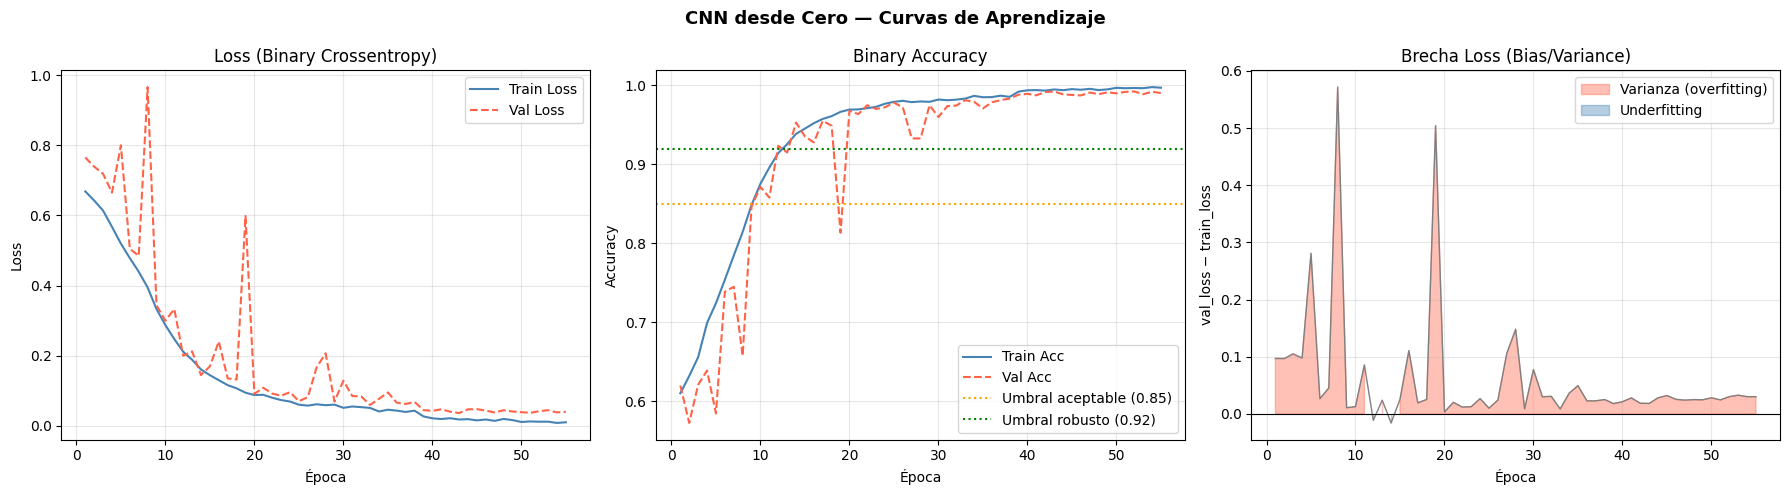

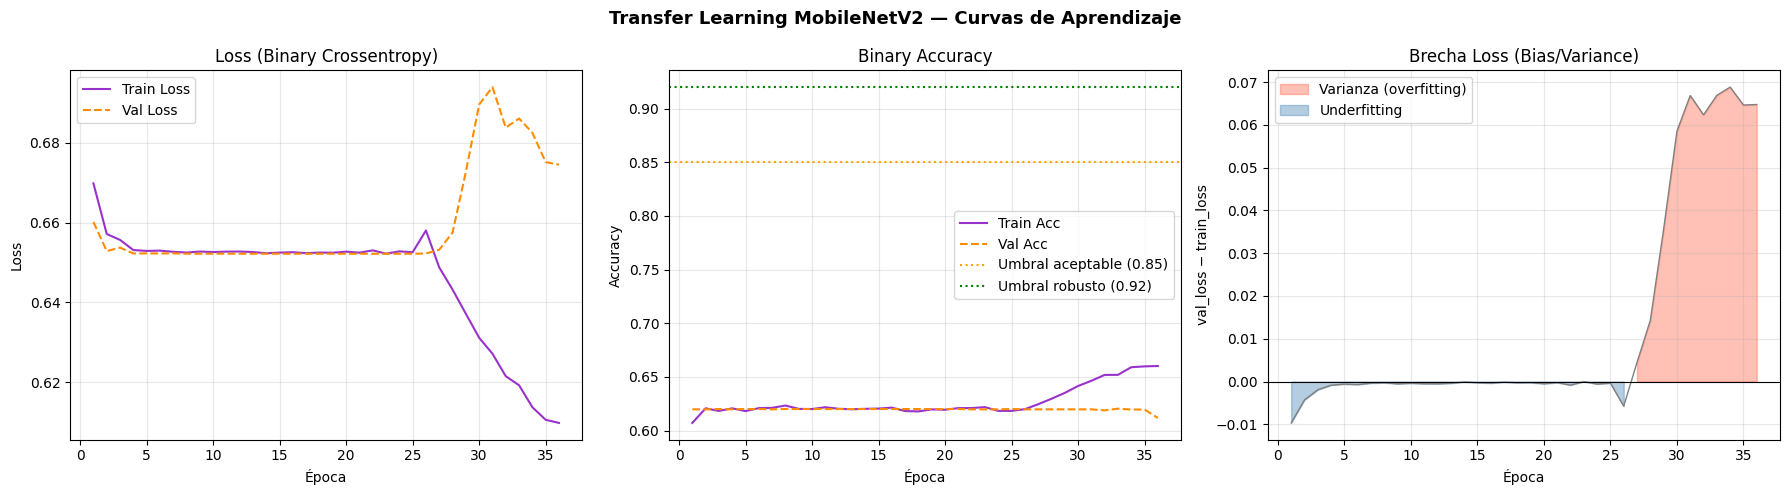


DIAGNÓSTICO: CNN desde Cero
  Train Loss final : 0.0098
  Val   Loss final : 0.0399
  Brecha (gap)     : 0.0300
  ✅  BALANCE OK — Bias y Variance bien equilibrados

DIAGNÓSTICO: Transfer Learning MobileNetV2
  Train Loss final : 0.6097
  Val   Loss final : 0.6745
  Brecha (gap)     : 0.0648
  ⚠️  ALTO BIAS (Underfitting) — aumenta capacidad o épocas


In [11]:
# ═══════════════════════════════════════════════════════
# CELDA 11: Curvas de aprendizaje + Diagnóstico Bias/Variance
# ═══════════════════════════════════════════════════════
def plot_learning_curves(hist, title, color_train='steelblue', color_val='tomato'):
    epochs = range(1, len(hist['loss']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    # Loss
    axes[0].plot(epochs, hist['loss'],          color=color_train, label='Train Loss')
    axes[0].plot(epochs, hist['val_loss'], '--', color=color_val,   label='Val Loss')
    axes[0].set_title('Loss (Binary Crossentropy)')
    axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Binary Accuracy
    axes[1].plot(epochs, hist['binary_accuracy'],          color=color_train, label='Train Acc')
    axes[1].plot(epochs, hist['val_binary_accuracy'], '--', color=color_val,   label='Val Acc')
    axes[1].axhline(THRESHOLD_ACCEPTABLE, color='orange', linestyle=':',
                    label=f'Umbral aceptable ({THRESHOLD_ACCEPTABLE})')
    axes[1].axhline(THRESHOLD_ROBUST, color='green', linestyle=':',
                    label=f'Umbral robusto ({THRESHOLD_ROBUST})')
    axes[1].set_title('Binary Accuracy')
    axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    # Brecha Bias / Variance
    gap = np.array(hist['val_loss']) - np.array(hist['loss'])
    axes[2].fill_between(epochs, gap, 0, where=(gap > 0),
                         alpha=0.4, color='tomato',    label='Varianza (overfitting)')
    axes[2].fill_between(epochs, gap, 0, where=(gap < 0),
                         alpha=0.4, color='steelblue', label='Underfitting')
    axes[2].plot(epochs, gap, color='gray', linewidth=1)
    axes[2].axhline(0, color='black', linewidth=0.8)
    axes[2].set_title('Brecha Loss (Bias/Variance)')
    axes[2].set_xlabel('Época'); axes[2].set_ylabel('val_loss − train_loss')
    axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    return fig

# Curvas CNN Scratch
fig_scratch = plot_learning_curves(history_scratch.history, "CNN desde Cero — Curvas de Aprendizaje")
fig_scratch.savefig('/content/curvas_scratch.png', dpi=150, bbox_inches='tight')
plt.show()

# Curvas Transfer Learning (unir fases 1 y 2)
def merge_histories(h1, h2):
    merged = {}
    for k in h1.history:
        if k in h2.history:
            merged[k] = h1.history[k] + h2.history[k]
    return merged

hist_tl_merged = merge_histories(history_p1, history_p2)
fig_tl = plot_learning_curves(hist_tl_merged, "Transfer Learning MobileNetV2 — Curvas de Aprendizaje",
                               color_train='darkorchid', color_val='darkorange')
fig_tl.savefig('/content/curvas_tl.png', dpi=150, bbox_inches='tight')
plt.show()

# Diagnóstico automático
def diagnose_bias_variance(hist, model_name):
    gap   = hist['val_loss'][-1] - hist['loss'][-1]
    print(f"\n{'='*50}")
    print(f"DIAGNÓSTICO: {model_name}")
    print(f"{'='*50}")
    print(f"  Train Loss final : {hist['loss'][-1]:.4f}")
    print(f"  Val   Loss final : {hist['val_loss'][-1]:.4f}")
    print(f"  Brecha (gap)     : {gap:.4f}")
    if hist['loss'][-1] > 0.15:
        print("  ⚠️  ALTO BIAS (Underfitting) — aumenta capacidad o épocas")
    elif gap > 0.05:
        print("  ⚠️  ALTA VARIANZA (Overfitting) — más regularización/augmentation")
    else:
        print("  ✅  BALANCE OK — Bias y Variance bien equilibrados")

diagnose_bias_variance(history_scratch.history, "CNN desde Cero")
diagnose_bias_variance(hist_tl_merged, "Transfer Learning MobileNetV2")

In [12]:
# ═══════════════════════════════════════════════════════
# CELDA 12: Evaluación en Test + Métricas de satisfacción
# ═══════════════════════════════════════════════════════
def evaluate_multilabel(model, test_generator, Y_test_raw, model_name, threshold=0.5):
    Y_pred_proba = model.predict(test_generator, verbose=0)
    Y_pred       = (Y_pred_proba >= threshold).astype(int)
    N            = len(Y_test_raw)
    Y_true       = Y_test_raw[:N]

    # ── Métricas de satisfacción ──
    exact_match  = accuracy_score(Y_true, Y_pred)          # EMR
    hamming_acc  = 1 - hamming_loss(Y_true, Y_pred)        # Hamming Accuracy
    macro_f1     = f1_score(Y_true, Y_pred, average='macro', zero_division=0)
    macro_prec   = precision_score(Y_true, Y_pred, average='macro', zero_division=0)
    macro_rec    = recall_score(Y_true, Y_pred, average='macro', zero_division=0)

    print(f"\n{'='*55}")
    print(f"EVALUACIÓN TEST — {model_name}")
    print(f"{'='*55}")
    print(f"  Exact Match Ratio (EMR) : {exact_match:.4f}  (umbral: {THRESHOLD_ACCEPTABLE})")
    print(f"  Hamming Accuracy        : {hamming_acc:.4f}  (umbral: 0.95)")
    print(f"  Macro F1-Score          : {macro_f1:.4f}")
    print(f"  Macro Precision         : {macro_prec:.4f}")
    print(f"  Macro Recall            : {macro_rec:.4f}")

    if exact_match >= THRESHOLD_ROBUST:
        print(f"\n  ✅ MODELO ROBUSTO — supera umbral {THRESHOLD_ROBUST}")
    elif exact_match >= THRESHOLD_ACCEPTABLE:
        print(f"\n  🟡 MODELO ACEPTABLE — supera umbral {THRESHOLD_ACCEPTABLE}")
    else:
        print(f"\n  ❌ INSUFICIENTE — no supera umbral {THRESHOLD_ACCEPTABLE}")

    # F1 por dedo
    print(f"\n  F1-Score por dedo:")
    f1_per = f1_score(Y_true, Y_pred, average=None, zero_division=0)
    for name, f1 in zip(FINGER_NAMES, f1_per):
        bar = "█" * int(f1 * 20)
        print(f"    {name:<10}: {f1:.3f}  {bar}")

    return Y_pred_proba, Y_pred, exact_match

Y_proba_scratch, Y_pred_scratch, emr_scratch = evaluate_multilabel(
    model_scratch, test_gen, Y_test, "CNN Scratch")

Y_proba_tl, Y_pred_tl, emr_tl = evaluate_multilabel(
    model_tl, test_gen, Y_test, "Transfer Learning MobileNetV2")


EVALUACIÓN TEST — CNN Scratch
  Exact Match Ratio (EMR) : 0.9831  (umbral: 0.85)
  Hamming Accuracy        : 0.9926  (umbral: 0.95)
  Macro F1-Score          : 0.9919
  Macro Precision         : 0.9941
  Macro Recall            : 0.9897

  ✅ MODELO ROBUSTO — supera umbral 0.92

  F1-Score por dedo:
    Pulgar    : 0.996  ███████████████████
    Índice    : 0.992  ███████████████████
    Medio     : 0.988  ███████████████████
    Anular    : 0.988  ███████████████████
    Meñique   : 0.996  ███████████████████

EVALUACIÓN TEST — Transfer Learning MobileNetV2
  Exact Match Ratio (EMR) : 0.1002  (umbral: 0.85)
  Hamming Accuracy        : 0.6203  (umbral: 0.95)
  Macro F1-Score          : 0.3000
  Macro Precision         : 0.2401
  Macro Recall            : 0.4000

  ❌ INSUFICIENTE — no supera umbral 0.85

  F1-Score por dedo:
    Pulgar    : 0.751  ███████████████
    Índice    : 0.750  ██████████████
    Medio     : 0.000  
    Anular    : 0.000  
    Meñique   : 0.000  


In [13]:
# ═══════════════════════════════════════════════════════
# CELDA 13: Análisis de errores por dedo
# ═══════════════════════════════════════════════════════
def error_analysis_per_finger(Y_true, Y_pred, Y_proba, model_name, real_indices):
    print(f"\n{'='*55}")
    print(f"ANÁLISIS DE ERRORES — {model_name}")
    print(f"{'='*55}")

    N = min(len(Y_true), len(Y_pred))
    Y_true = Y_true[:N]
    Y_pred = Y_pred[:N]
    Y_proba = Y_proba[:N]

    # Errores totales por dedo
    errors_per_finger = (Y_true != Y_pred).sum(axis=0)
    print(f"\n  Errores por dedo (de {N} muestras):")
    for name, err in zip(FINGER_NAMES, errors_per_finger):
        rate = err / N
        print(f"    {name:<10}: {err:4d} errores  ({rate:.2%})  {'⚠️' if rate > 0.10 else '✅'}")

    # Falsos positivos vs Falsos negativos
    FP = ((Y_pred == 1) & (Y_true == 0)).sum(axis=0)
    FN = ((Y_pred == 0) & (Y_true == 1)).sum(axis=0)
    print(f"\n  Falsos Positivos (dedo predicho=1, real=0):")
    for name, fp in zip(FINGER_NAMES, FP):
        print(f"    {name:<10}: {fp}")
    print(f"\n  Falsos Negativos (dedo predicho=0, real=1):")
    for name, fn in zip(FINGER_NAMES, FN):
        print(f"    {name:<10}: {fn}")

    # Errores de alta confianza (confianza > 0.8 pero equivocado)
    max_conf      = Y_proba.max(axis=1)
    exact_correct = (Y_true == Y_pred).all(axis=1)
    high_conf_err = (~exact_correct) & (max_conf > 0.80)
    print(f"\n  Errores con confianza > 0.80: {high_conf_err.sum()} "
          f"({100*high_conf_err.mean():.1f}%)")

    return errors_per_finger

errors_s = error_analysis_per_finger(
    Y_test, Y_pred_scratch, Y_proba_scratch, "CNN Scratch", real_idx_test)

errors_tl = error_analysis_per_finger(
    Y_test, Y_pred_tl, Y_proba_tl, "Transfer Learning", real_idx_test)


ANÁLISIS DE ERRORES — CNN Scratch

  Errores por dedo (de 1298 muestras):
    Pulgar    :    7 errores  (0.54%)  ✅
    Índice    :   13 errores  (1.00%)  ✅
    Medio     :   16 errores  (1.23%)  ✅
    Anular    :    9 errores  (0.69%)  ✅
    Meñique   :    3 errores  (0.23%)  ✅

  Falsos Positivos (dedo predicho=1, real=0):
    Pulgar    : 5
    Índice    : 6
    Medio     : 5
    Anular    : 2
    Meñique   : 1

  Falsos Negativos (dedo predicho=0, real=1):
    Pulgar    : 2
    Índice    : 7
    Medio     : 11
    Anular    : 7
    Meñique   : 2

  Errores con confianza > 0.80: 21 (1.6%)

ANÁLISIS DE ERRORES — Transfer Learning

  Errores por dedo (de 1298 muestras):
    Pulgar    :  518 errores  (39.91%)  ⚠️
    Índice    :  520 errores  (40.06%)  ⚠️
    Medio     :  648 errores  (49.92%)  ⚠️
    Anular    :  389 errores  (29.97%)  ⚠️
    Meñique   :  389 errores  (29.97%)  ⚠️

  Falsos Positivos (dedo predicho=1, real=0):
    Pulgar    : 518
    Índice    : 520
    Medio     : 0
 

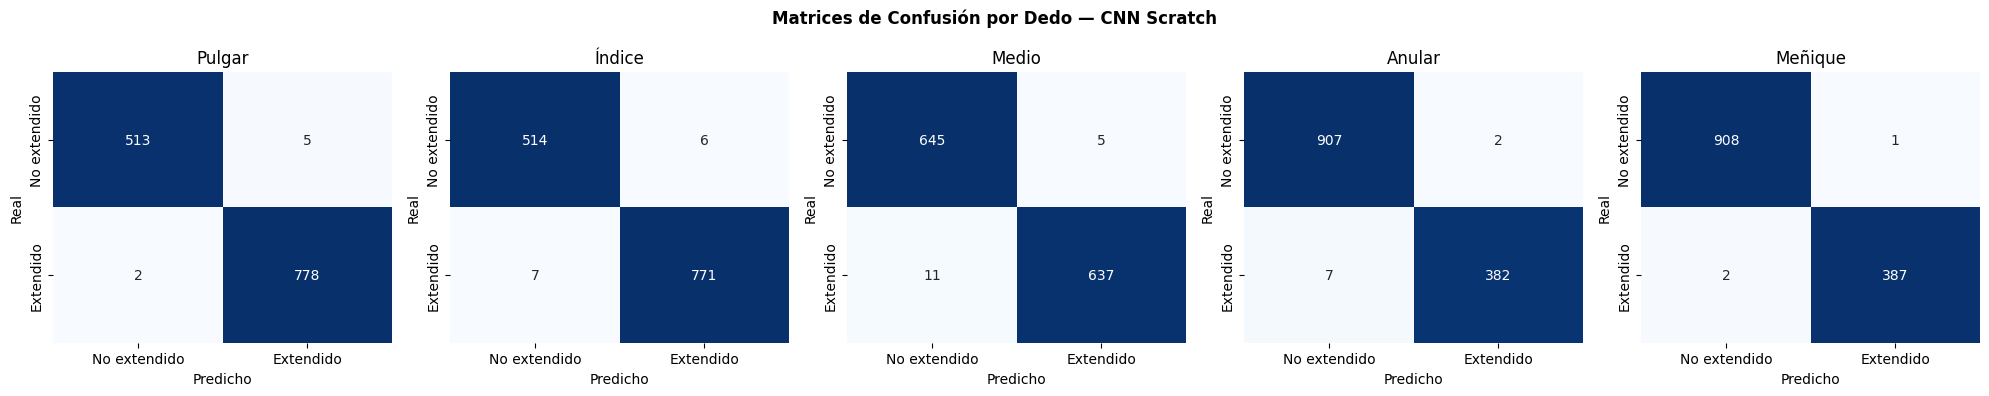

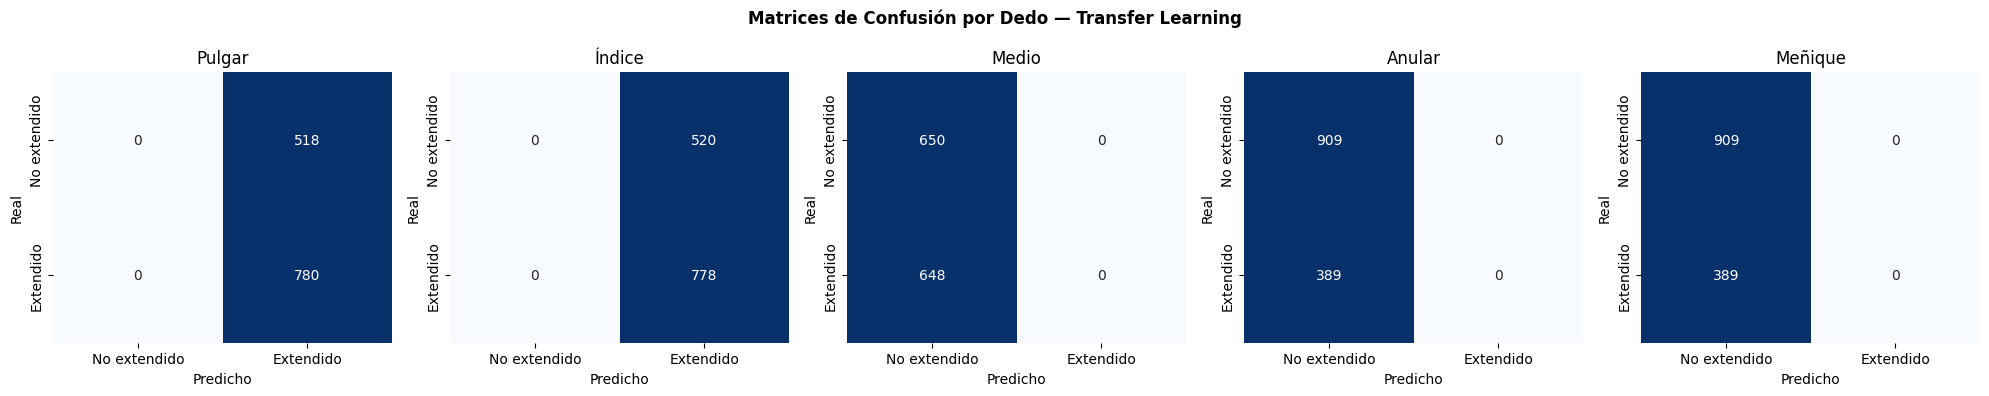

In [14]:
# ═══════════════════════════════════════════════════════
# CELDA 14: Matrices de confusión por dedo (multi-label)
# ═══════════════════════════════════════════════════════
def plot_multilabel_confusion(Y_true, Y_pred, title, filename):
    N = min(len(Y_true), len(Y_pred))
    mcm = multilabel_confusion_matrix(Y_true[:N], Y_pred[:N])

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle(title, fontsize=12, fontweight='bold')

    for i, (ax, cm) in enumerate(zip(axes, mcm)):
        cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
        sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['No extendido', 'Extendido'],
                    yticklabels=['No extendido', 'Extendido'],
                    cbar=False)
        ax.set_title(FINGER_NAMES[i])
        ax.set_xlabel('Predicho'); ax.set_ylabel('Real')

    plt.tight_layout()
    fig.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

plot_multilabel_confusion(
    Y_test, Y_pred_scratch,
    "Matrices de Confusión por Dedo — CNN Scratch",
    '/content/conf_matrix_scratch.png')

plot_multilabel_confusion(
    Y_test, Y_pred_tl,
    "Matrices de Confusión por Dedo — Transfer Learning",
    '/content/conf_matrix_tl.png')


       COMPARACIÓN FINAL: SCRATCH vs TRANSFER LEARNING
Métrica                  CNN Scratch  Transfer Learning   Ganancia
------------------------------------------------------------
EMR                           0.9831             0.1002   -0.8829 ↓
Hamming Acc                   0.9926             0.6203   -0.3723 ↓
Macro F1                      0.9919             0.3000   -0.6918 ↓


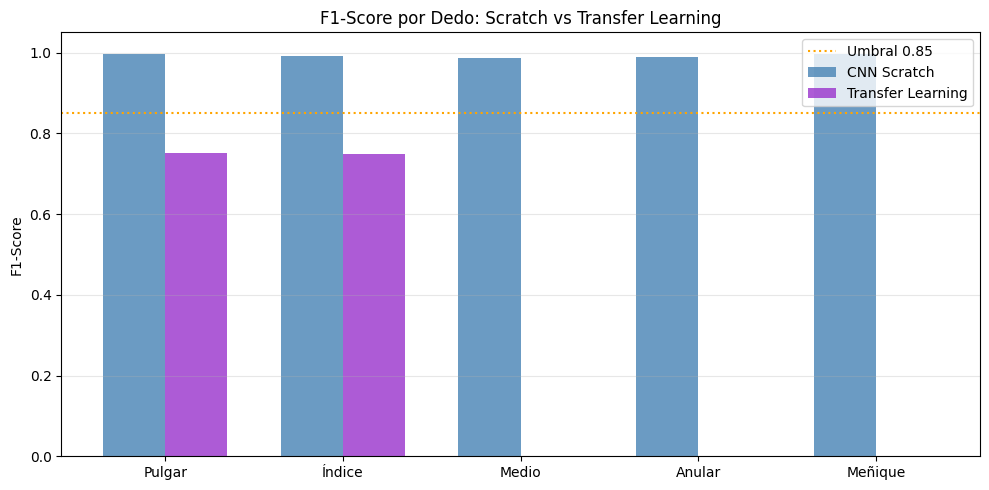

In [15]:
# ═══════════════════════════════════════════════════════
# CELDA 15: Comparación final ambos modelos
# ═══════════════════════════════════════════════════════
from sklearn.metrics import f1_score as f1

def get_metrics(Y_true, Y_pred):
    N = min(len(Y_true), len(Y_pred))
    return {
        "EMR"        : accuracy_score(Y_true[:N], Y_pred[:N]),
        "Hamming Acc": 1 - hamming_loss(Y_true[:N], Y_pred[:N]),
        "Macro F1"   : f1(Y_true[:N], Y_pred[:N], average='macro', zero_division=0),
    }

m_scratch = get_metrics(Y_test, Y_pred_scratch)
m_tl      = get_metrics(Y_test, Y_pred_tl)

print("\n" + "="*60)
print("       COMPARACIÓN FINAL: SCRATCH vs TRANSFER LEARNING")
print("="*60)
print(f"{'Métrica':<20} {'CNN Scratch':>15} {'Transfer Learning':>18} {'Ganancia':>10}")
print("-"*60)
for k in m_scratch:
    diff = m_tl[k] - m_scratch[k]
    icon = "↑" if diff > 0 else "↓"
    print(f"{k:<20} {m_scratch[k]:>15.4f} {m_tl[k]:>18.4f} {diff:>+9.4f} {icon}")
print("="*60)

# Gráfica comparativa por dedo
f1_scratch_per = f1(Y_test, Y_pred_scratch, average=None, zero_division=0)
f1_tl_per      = f1(Y_test, Y_pred_tl,      average=None, zero_division=0)

x = np.arange(5)
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, f1_scratch_per, width, label='CNN Scratch', color='steelblue', alpha=0.8)
ax.bar(x + width/2, f1_tl_per,      width, label='Transfer Learning', color='darkorchid', alpha=0.8)
ax.axhline(THRESHOLD_ACCEPTABLE, color='orange', linestyle=':', label=f'Umbral {THRESHOLD_ACCEPTABLE}')
ax.set_xticks(x); ax.set_xticklabels(FINGER_NAMES)
ax.set_ylabel('F1-Score'); ax.set_title('F1-Score por Dedo: Scratch vs Transfer Learning')
ax.legend(); ax.grid(axis='y', alpha=0.3); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('/content/comparison_f1.png', dpi=150, bbox_inches='tight')
plt.show()